In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

8691
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/sim_diag"
for i in range(100):
    plt.close()

In [5]:
# -------------------------------------------------------------------
# --- Helper functions ---
# -------------------------------------------------------------------
def plot_2D(X, Y, f, str_title="", fontsize = 30,):
    fig = plt.figure(figsize=(11,10))
    ax = fig.add_subplot(111)

    f_max_loc = np.max(np.abs(f))

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize)

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 
    offset_text.set_x(4) 

    ax.set_xlabel('$\\theta/\pi$', fontsize = fontsize)
    ax.set_ylabel("$\phi/\pi$", fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()
    return
# ----------------------------------------------------------
def plot_2D_subplot(
        ax, fig, X, Y, f, 
        str_title="", 
        fontsize = 30, 
        label_x = '$\\theta\'/\pi$', label_y = "$\phi\'/\pi$",
        flag_x = True, flag_y = True
):
    f_max_loc = np.max(np.abs(f))
    f_min_loc = np.min(f)

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    # levels = np.linspace(f_min_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize)

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 
    offset_text.set_x(4) 

    ax.set_xlabel(label_x, fontsize = fontsize)
    ax.set_ylabel(label_y, fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()

    if not flag_x:
        ax.set_xticklabels([])
    if not flag_y:
        ax.set_yticklabels([])

    return
# ----------------------------------------------------------
def rearrange_into_2d(y, N):
    y_new = np.zeros((N, N), dtype = y.dtype)
    for ic in range(N):
        for ir in range(N):
            y_new[ir, ic] = y[ir + ic * N]
    return y_new
# ----------------------------------------------------------
def change_coord_to_orig(psi, Nx):
    y_orig = np.array(psi.real.transpose())
    y_new  = np.zeros((Nx, Nx))
    for ir in range(Nx):
        for ic in range(Nx):
            ic_new = ic + ir
            if ic_new >= Nx:
                ic_new = ic_new - Nx
            y_new[ir, ic_new] = y_orig[ir, ic]
    return y_new
# ----------------------------------------------------------

In [13]:
# -------------------------------------------------------------------
# --- Main parameters ---
# -------------------------------------------------------------------
def plot_init(x):
    Nx = len(x)
    y_2D = f_init_2d_(x, Nx)

    # --- Plotting 2D ---
    X, Y = np.meshgrid(x/np.pi, x/np.pi)
    plot_2D(X, Y, y_2D, "initial conditions in modified coordinates")
    return
# -----------------------------------------------------
def compute_QuCF_parameters_for_initialization(N):
    # --- Initialization for angle = [0, np.pi] ---
    alpha_0 = 0.
    alpha_1 = np.pi * N/(2.*(N - 1))

    n = int(np.log2(N))
    nD = 2 * n

    # --- for QSP: for angle = [0, 2*np.pi] ---
    alpha_0_qsp = 0.
    alpha_1_qsp = (2. * np.pi) * N/(2.*(N - 1))

    # --- Printing ---
    print()
    print("// --- For spatial and time grids ---")
    print("\tNt \t{:d}".format(Nt_))
    print("\tnx \t{:d}".format(n))
    print("\tnxD \t{:d}".format(nD))
    print("// --- For initialization subcircuit ---")
    print("\talpha_init_0 \t{:0.12e}".format(alpha_0))
    print("\talpha_init_1 \t{:0.12e}".format(alpha_1))
    print("// --- For QSP BE sin oracle ---")
    print("\talpha_qsp_0 \t{:0.12e}".format(alpha_0_qsp))
    print("\talpha_qsp_1 \t{:0.12e}".format(alpha_1_qsp))
    return
# -----------------------------------------------------
def f_init_1d_(x):
    f_loc = lambda x1: np.exp(kappa_ * np.sin(x1/2.)**2) - 1
    y = f_loc(x) / f_loc(np.pi)
    return y
# -----------------------------------------------------
def f_init_2d_(x, Nx):
    g_cl = f_init_1d_(x)

    y_2D = np.zeros((Nx, Nx))
    f_loc = lambda x1, x2: np.exp(kappa_ * np.sin((x1 + x2)/2.)**2) - 1
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            y_2D[i_theta, i_phi] = f_loc(x[i_theta], x[i_phi]) * g_cl[i_phi]
    y_2D /= f_loc(np.pi, 0.)
    return y_2D
# -----------------------------------------------------
def create_diag_matrix(t, N_half, alpha, name_matrix, flag_cut):
    if not flag_cut:
        N = 2 * N_half + 1
        c_arr = np.arange(-N_half, N_half+1)
    else:
        N = 2 * N_half
        c_arr = np.arange(-N_half, N_half)

    aa = np.linspace(0, 2.*np.pi, N)
    diag = np.zeros(N**2)
    count = -1

    if name_matrix == "M1":
        for i2 in range(N):
            for i1 in range(N):
                count += 1
                diag[count] = - (1. - alpha) * c_arr[i1] * (1. - np.cos(aa[i2]))

    if name_matrix == "M2":
        for i2 in range(N):
            for i1 in range(N):
                count += 1
                diag[count] = - alpha * c_arr[i2] * (1. - np.cos(aa[i1]))

    # --- reference unitary matrix ---
    Nsq = N**2
    diag_U_ref = np.zeros(Nsq, dtype = complex)
    for ii in range(Nsq):
        diag_U_ref[ii] = np.exp(-1j * t * diag[ii])
    return diag_U_ref
# -----------------------------------------------------
dt_, Nt_ = 0.1, 40   # total time interval is dt_ * Nt_
nx_ = 6
file_qucf_ = "sim"

alpha_ = np.sqrt(20.)
kappa_ = 1.

# --- spatial grid ---
Nx_ = 1 << nx_
nx_half_ = nx_ - 1
Nx_half_ = 1 << nx_half_
x_ = np.linspace(0., 2.*np.pi, Nx_)

# --- initialization ---
compute_QuCF_parameters_for_initialization(Nx_)
# plot_init(x_)

# --- unitary operators ---
init_2d_    = f_init_2d_(x_, Nx_)
diag_U_M1_  = create_diag_matrix(dt_, Nx_half_, alpha_, "M1", True)
diag_U_M2_  = create_diag_matrix(dt_, Nx_half_, alpha_, "M2", True)


// --- For spatial and time grids ---
	Nt 	40
	nx 	6
	nxD 	12
// --- For initialization subcircuit ---
	alpha_init_0 	0.000000000000e+00
	alpha_init_1 	1.595729601823e+00
// --- For QSP BE sin oracle ---
	alpha_qsp_0 	0.000000000000e+00
	alpha_qsp_1 	3.191459203647e+00


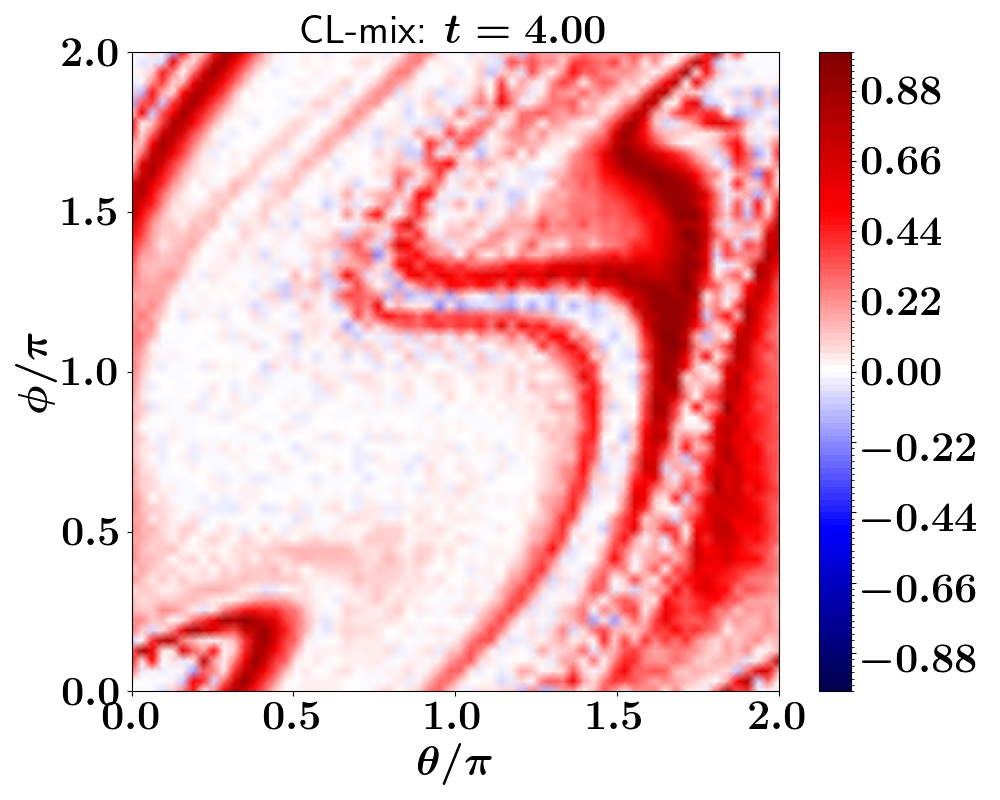

In [14]:
# -------------------------------------------------------------------
# --- Classical simulations in real-Fourier space  ---
# -------------------------------------------------------------------
def computation_in_real_and_fourier_CLASSICAL(diag_U_M1, diag_U_M2, init_2d):
    def evolution_one_matrix(psi_init_x, id_axis):
        init_fft_2d = np.fft.fft(psi_init_x, axis = id_axis)
        init_fft_2d = np.fft.fftshift(init_fft_2d, axes = id_axis)
        init_fft_1d = init_fft_2d.flatten(order = "F")  # CHECK; 

        if id_axis == 0:
            psi_t_fourier_1D = diag_U_M1 * init_fft_1d
        else:
            psi_t_fourier_1D = diag_U_M2 * init_fft_1d

        psi_t_fourier_2D = rearrange_into_2d(psi_t_fourier_1D, Nx_)
        psi_t_fourier_2D = np.fft.ifftshift(psi_t_fourier_2D, axes = id_axis)
        psi_t_x = np.fft.ifft(psi_t_fourier_2D, axis = id_axis)
        return psi_t_x
    # ----------------------------------------------------------

    # --- Computation ---
    psi_t_x = np.array(init_2d)
    for ii_t in range(Nt_):
        # --- evolution in Fourier over theta ---
        psi_t_x = evolution_one_matrix(psi_t_x, 0)

        # --- evolution in Fourier over phi ---
        psi_t_x = evolution_one_matrix(psi_t_x, 1)

    # --- Change of coordinates back to the original ---
    y_res_cl = change_coord_to_orig(psi_t_x, Nx_)
    y_res_cl /= np.max(np.abs(y_res_cl)) 

    # --- Plotting ---
    X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
    fig1, axs = plt.subplots(1, 1, figsize=(10,8))
    plot_2D_subplot(
        axs, fig1, X, Y, y_res_cl,  
        str_title="CL-mix: $" + "t={:0.2f}".format(Nt_*dt_) + "$", 
        label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
    )
    plt.tight_layout()
    return y_res_cl
# ------------------------------------------------------------------------
y_cl_mix_ = computation_in_real_and_fourier_CLASSICAL(diag_U_M1_, diag_U_M2_, init_2d_)

--- Looking for the file: Stepanoff_data_k1.0_a4.472_n6.hdf5 in the path ./jupyter-notebooks/Stepanoff/results/
--- Loading data ---
Reading the coefficients from:
 ./jupyter-notebooks/Stepanoff/results/Stepanoff_data_k1.0_a4.472_n6.hdf5

Take the Dopri simulation at t = 4


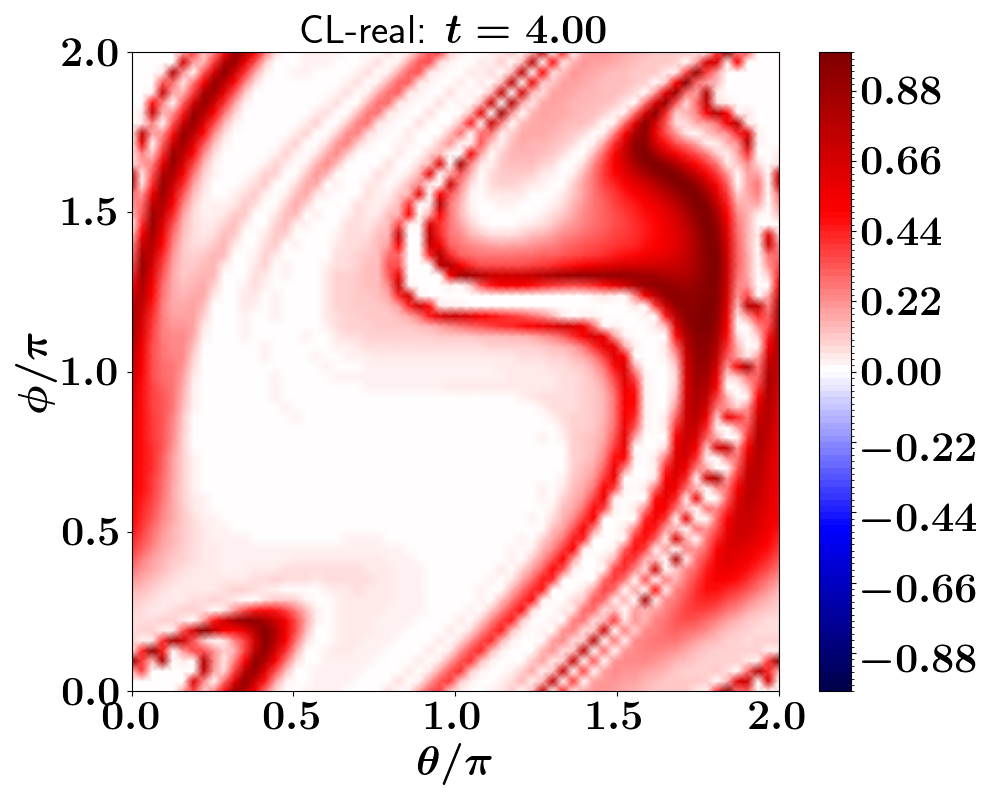

In [15]:
# -------------------------------------------------------------------
# --- Classical simulations in real space  ---
# -------------------------------------------------------------------
def form_file_name(alpha, kappa, nx):
    file_name = "Stepanoff_data_k{:0.1f}_a{:0.3f}_n{:d}.hdf5".format(kappa, alpha, nx)
    return file_name
# -----------------------------------------------------------------------------------
def load_data(full_name):
    print("Reading the coefficients from:\n " + full_name)
    with h5py.File(full_name, "r") as f:
        grp = f["basic"]

        nx = int(grp["nx"][()])
        N_data = int(grp["N_data"][()])
        alpha = grp["alpha"][()]
        kappa = grp["kappa"][()]
        theta = np.array(grp["theta"])

        fx_arr = []
        t_arr  = []
        for id_data in range(N_data):
            grp = f["data_{:d}".format(id_data)]
            fx = np.array(grp["fx"])
            t  = float(grp["t"][()])
            fx_arr.append(fx)
            t_arr.append(t)

    # --- Form grids ---
    Nx = 1 << nx
    x1, x2 = np.meshgrid(theta, theta)
    x = np.concatenate((x1[:, :, np.newaxis], x2[:, :, np.newaxis]), axis=2)
    x1 = x1 / np.pi
    x2 = x2 / np.pi
    x = np.reshape(x, (Nx ** 2, 2))

    return fx_arr, t_arr, Nx, nx, alpha, kappa, x1, x2, x
# -----------------------------------------------------------------------------------
def get_Dopri_classical_simulations():
    full_name = form_file_name(alpha_, kappa_, nx_)

    print("--- Looking for the file: {:s} in the path {:s}".format(full_name, path_save_))
    full_name = os.path.join(path_save_, full_name)
    if os.path.isfile(full_name):
        print("--- Loading data ---")
        y_cl_dopri_arr, t_arr, _, _, _, _, _, _, _, = load_data(full_name)
    else:
        print("file is not found")

    # --- Find a necessary simulation ---
    t_ref = int(Nt_ * dt_)
    t_arr_ = np.array(t_arr, dtype = int)
    pos_arr = np.where(t_arr_ == t_ref)[0][0]
    print()
    print("Take the Dopri simulation at t = {:d}".format(t_arr_[pos_arr]))
    y_cl_dopri_1d = y_cl_dopri_arr[pos_arr]

    # --- Normalize to 1 ---
    y_cl_dopri_1d /= np.max(np.abs(y_cl_dopri_1d))

    # --- from 1D to 2D ---
    # y_cl_dopri_2d = rearrange_into_2d(y_cl_dopri_1d, Nx_)
    y_cl_dopri_2d = np.reshape(y_cl_dopri_1d, (Nx_, Nx_)) 

    # --- Plotting ---
    X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
    fig1, axs = plt.subplots(1, 1, figsize=(10,8))
    plot_2D_subplot(
        axs, fig1, X, Y, y_cl_dopri_2d,  
        str_title="CL-real: $" + "t={:0.2f}".format(Nt_*dt_) + "$", 
        label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
    )
    plt.tight_layout()

    return y_cl_dopri_2d
# -----------------------------------------------------------------------------------
y_cl_dopri_ = get_Dopri_classical_simulations()


Reading the file ../QuCF/simulations/Stepanoff/sim_diag/sim_n6_t4_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 14:30:00

A-max: 5.332393693547e-02
success prob: 9.999e-01
N-gates: 1057614
max. abs. err (mix  space): 3.662e-09
max. abs. err (real space): 1.093e+00


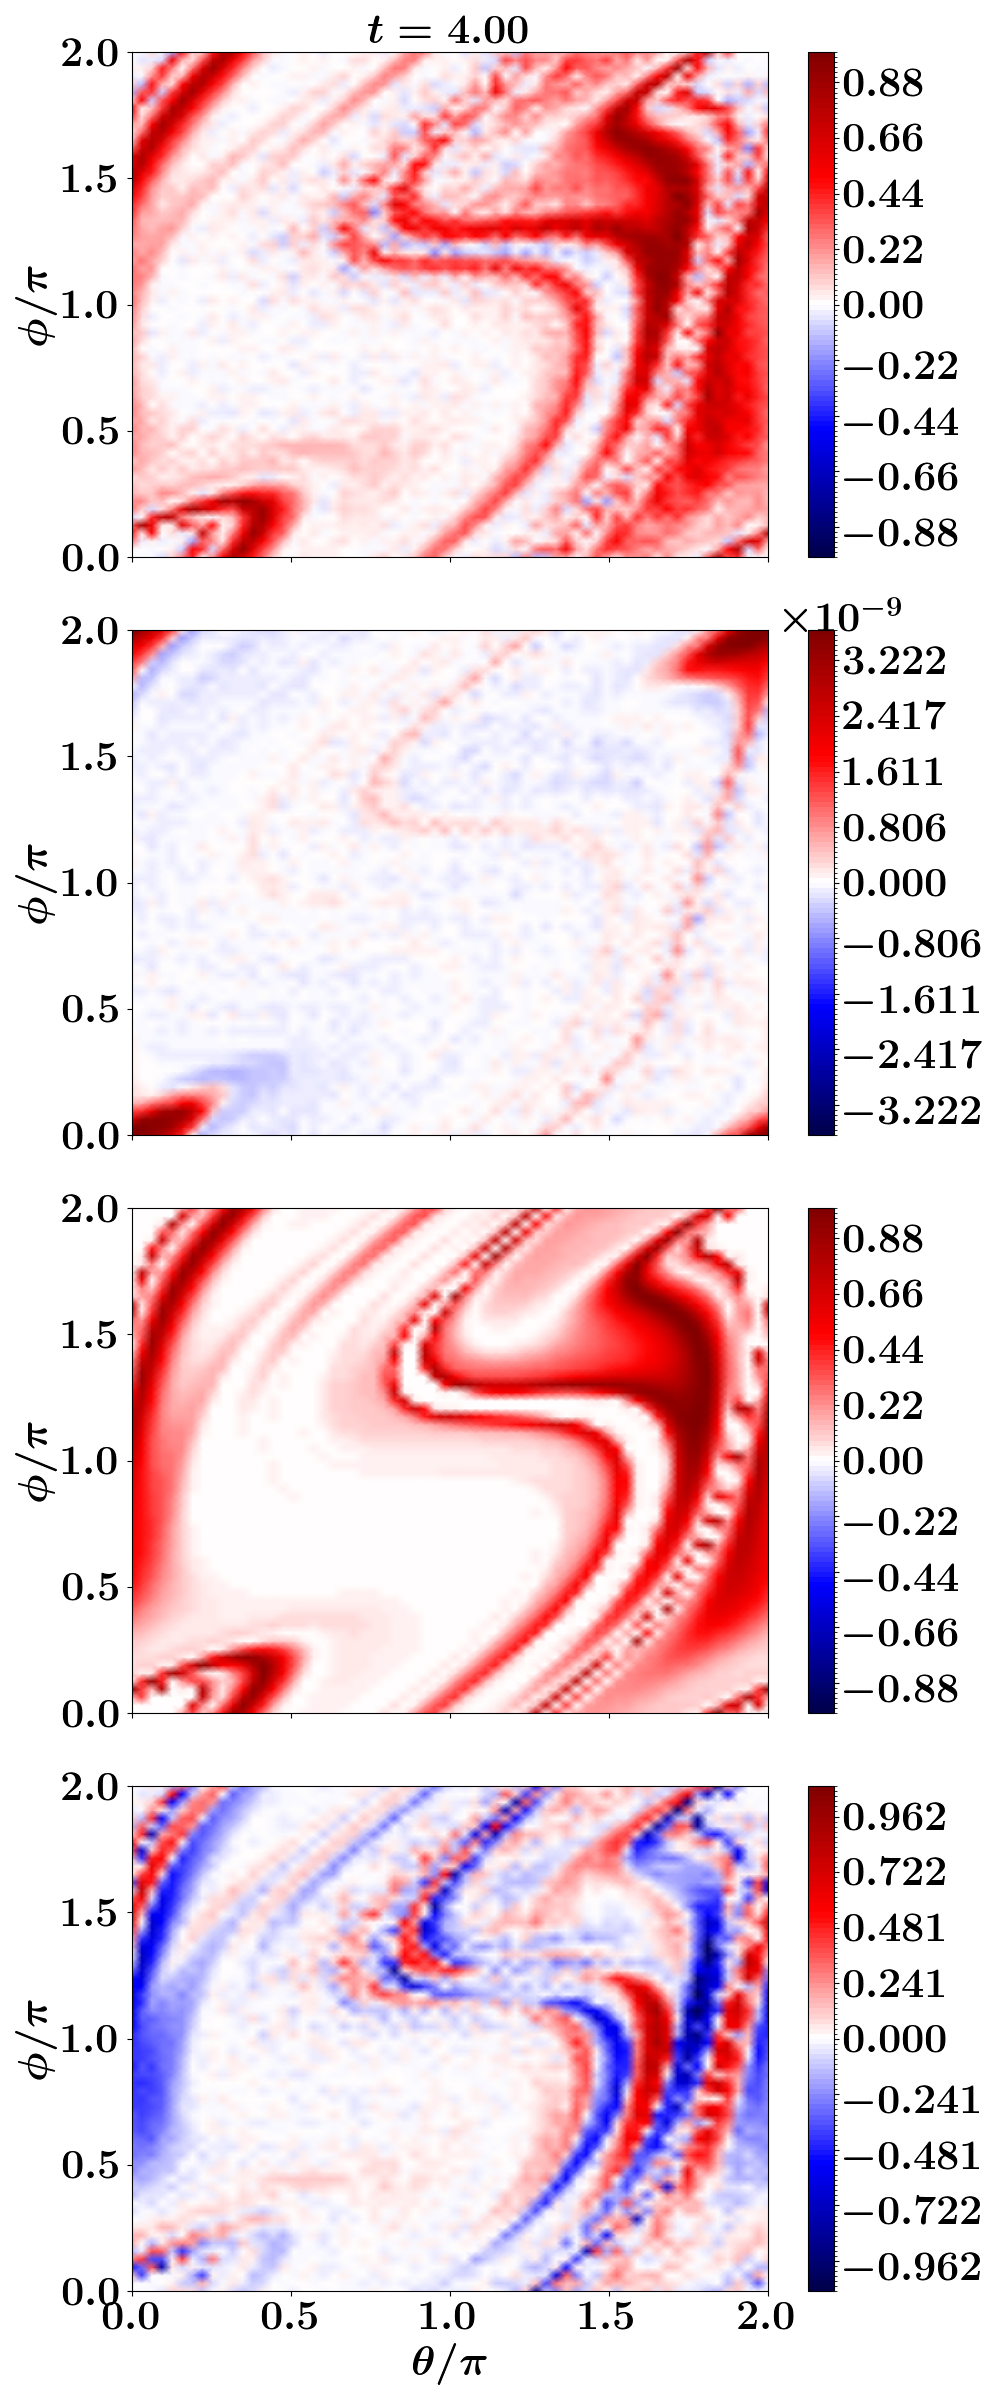

In [16]:
# -------------------------------------------------------------------
# --- Compare classical and QuCF results ---
# -------------------------------------------------------------------
def read_qc_data(path_qc, name_file_qc):
    print()  

    # --- Read the _OUTPUT.hdf5 file ---
    om = mse.MeasOracle__()
    om.path_  = path_qc
    om.pname_ = name_file_qc
    om.open()
    
    # --- get the result ---
    Ngates = om.dd_["N-gates"]
    om.set_zero_ancillae_work_states(0)
    qc_state = om.get_var_x({}, "r")
    
    print()
    print("A-max: {:0.12e}".format(np.max(np.abs(qc_state))))
    print("success prob: {:0.3e}".format(  np.sum(np.abs(qc_state)**2)  ))
    print("N-gates: {:d}".format(Ngates))

    # # --- normalize to 1 ---
    # qc_state /= np.max(np.abs(qc_state)) 

    return qc_state
# -------------------------------------------------------------------
def compare_classical_qucf(path_qucf, y_cl_mix, y_cl_dopri, file_qucf):
    # --- QuCF data ---
    psi_qc_1d = read_qc_data(path_qucf, file_qucf)

    psi_qc_1d_real = psi_qc_1d.real
    psi_qc_2d = rearrange_into_2d(psi_qc_1d_real, Nx_)

    # --- Change of coordinates back to the original ---
    y_res_qc = change_coord_to_orig(psi_qc_2d, Nx_)
    y_res_qc /= np.max(np.abs(y_res_qc)) 

    # --- Error ---
    err_mix = y_res_qc - y_cl_mix
    max_abs_err_mix = np.max(np.abs(err_mix))

    err_real = y_res_qc - y_cl_dopri
    max_abs_err_real = np.max(np.abs(err_real))

    print("max. abs. err (mix  space): {:0.3e}".format(max_abs_err_mix))
    print("max. abs. err (real space): {:0.3e}".format(max_abs_err_real))

    # --- Plotting ---
    X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
    fig1, axs = plt.subplots(4, 1, figsize=(10,24))
    plot_2D_subplot(
        axs[0], fig1, X, Y, y_res_qc,  
        str_title="$" + "t={:0.2f}".format(Nt_*dt_) + "$", 
        label_x = '', label_y = "$\phi/\pi$", 
        flag_x = False
    )
    plot_2D_subplot(
        axs[1], fig1, X, Y, err_mix,   
        label_x = '', label_y = "$\phi/\pi$",
        flag_x = False
    )
    plot_2D_subplot(
        axs[2], fig1, X, Y, y_cl_dopri,  
        label_x = '', label_y = "$\phi/\pi$", 
        flag_x = False
    )
    plot_2D_subplot(
        axs[3], fig1, X, Y, err_real,  
        label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
    )
    plt.tight_layout()
    return
# ----------------------------------------------------------------------
# compare_classical_qucf(path_qucf_, init_2d_, file_qucf_)

file_output = "sim_n{:d}_t{:d}".format(nx_, int(Nt_*dt_))
compare_classical_qucf(path_qucf_, y_cl_mix_, y_cl_dopri_, file_output)

In [26]:
64 * 64

4096

In [98]:
# -------------------------------------------------------------------
# --- QuCF results: testing ---
# -------------------------------------------------------------------
def read_qc_data(path_qc, name_file_qc):
    print()  

    # --- Read the _OUTPUT.hdf5 file ---
    om = mse.MeasOracle__()
    om.path_  = path_qc
    om.pname_ = name_file_qc
    om.open()
    
    # --- get the result ---
    Ngates = om.dd_["N-gates"]
    om.set_zero_ancillae_work_states(0)
    qc_state = om.get_var_x({}, "r")
    
    print()
    print("A-max: {:0.12e}".format(np.max(np.abs(qc_state))))
    print("success prob: {:0.3e}".format(  np.sum(np.abs(qc_state)**2)  ))
    print("N-gates: {:d}".format(Ngates))

    # --- normalize to 1 ---
    qc_state /= np.max(np.abs(qc_state)) 

    return qc_state
# -------------------------------------------------------------------
def analyse_qucf_data_test(path_qucf, file_qucf):
    psi_qc_1d = read_qc_data(path_qucf, file_qucf)

    mix.print_array(psi_qc_1d, ff = [22, 3, "e"], n_in_row = Nx_)

    # psi_qc_1d_real = psi_qc_1d.real
    # psi_qc_2d = rearrange_into_2d(psi_qc_1d_real, Nx_)

    # # --- change of coordinates back to the original ---
    # y_orig = np.array(psi_qc_2d.real.transpose())
    # y_new  = np.zeros((Nx_, Nx_))
    # for ir in range(Nx_):
    #     for ic in range(Nx_):
    #         ic_new = ic + ir
    #         if ic_new >= Nx_:
    #             ic_new = ic_new - Nx_
    #         y_new[ir, ic_new] = y_orig[ir, ic]
    return
# ----------------------------------------------------------------------
analyse_qucf_data_test(path_qucf_, file_qucf_)


Reading the file ../QuCF/simulations/Stepanoff/sim_diag/sim_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 13:20:18

A-max: 4.483282401835e-01
success prob: 9.191e-01
N-gates: 3347
  0.000e+00+0.000e+00j  -6.546e-13+5.141e-25j  -6.544e-13-5.143e-25j   0.000e+00+0.000e+00j 
  9.232e-01-1.884e-01j   5.477e-01+1.884e-01j   1.659e-01-1.884e-01j   9.821e-01+1.884e-01j 
  5.477e-01+1.884e-01j   1.659e-01-1.884e-01j   9.821e-01+1.884e-01j   9.232e-01-1.884e-01j 
  0.000e+00+0.000e+00j  -6.547e-13+5.143e-25j  -6.545e-13-5.145e-25j   0.000e+00+0.000e+00j 


Reading the file ../QuCF/simulations/Stepanoff/sim_diag/sim_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 13:56:19
max-abs-err: 1.617e-12
max-diff-abs-err: 1.617e-12


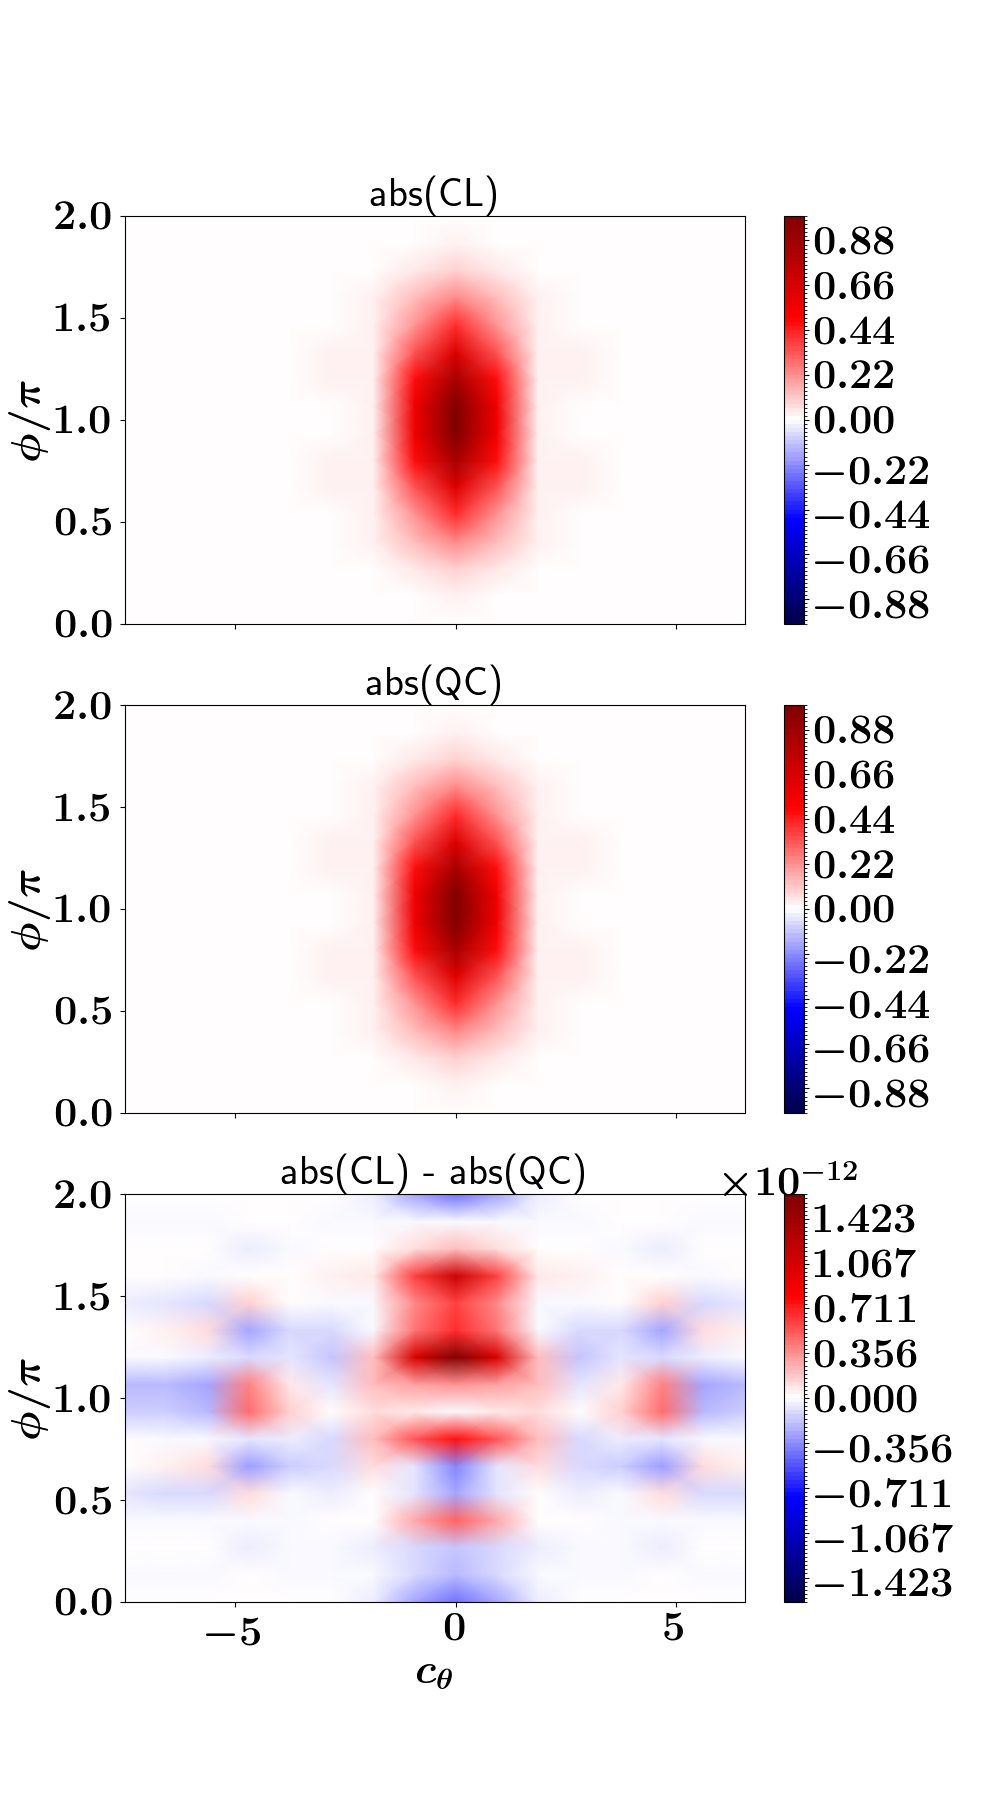

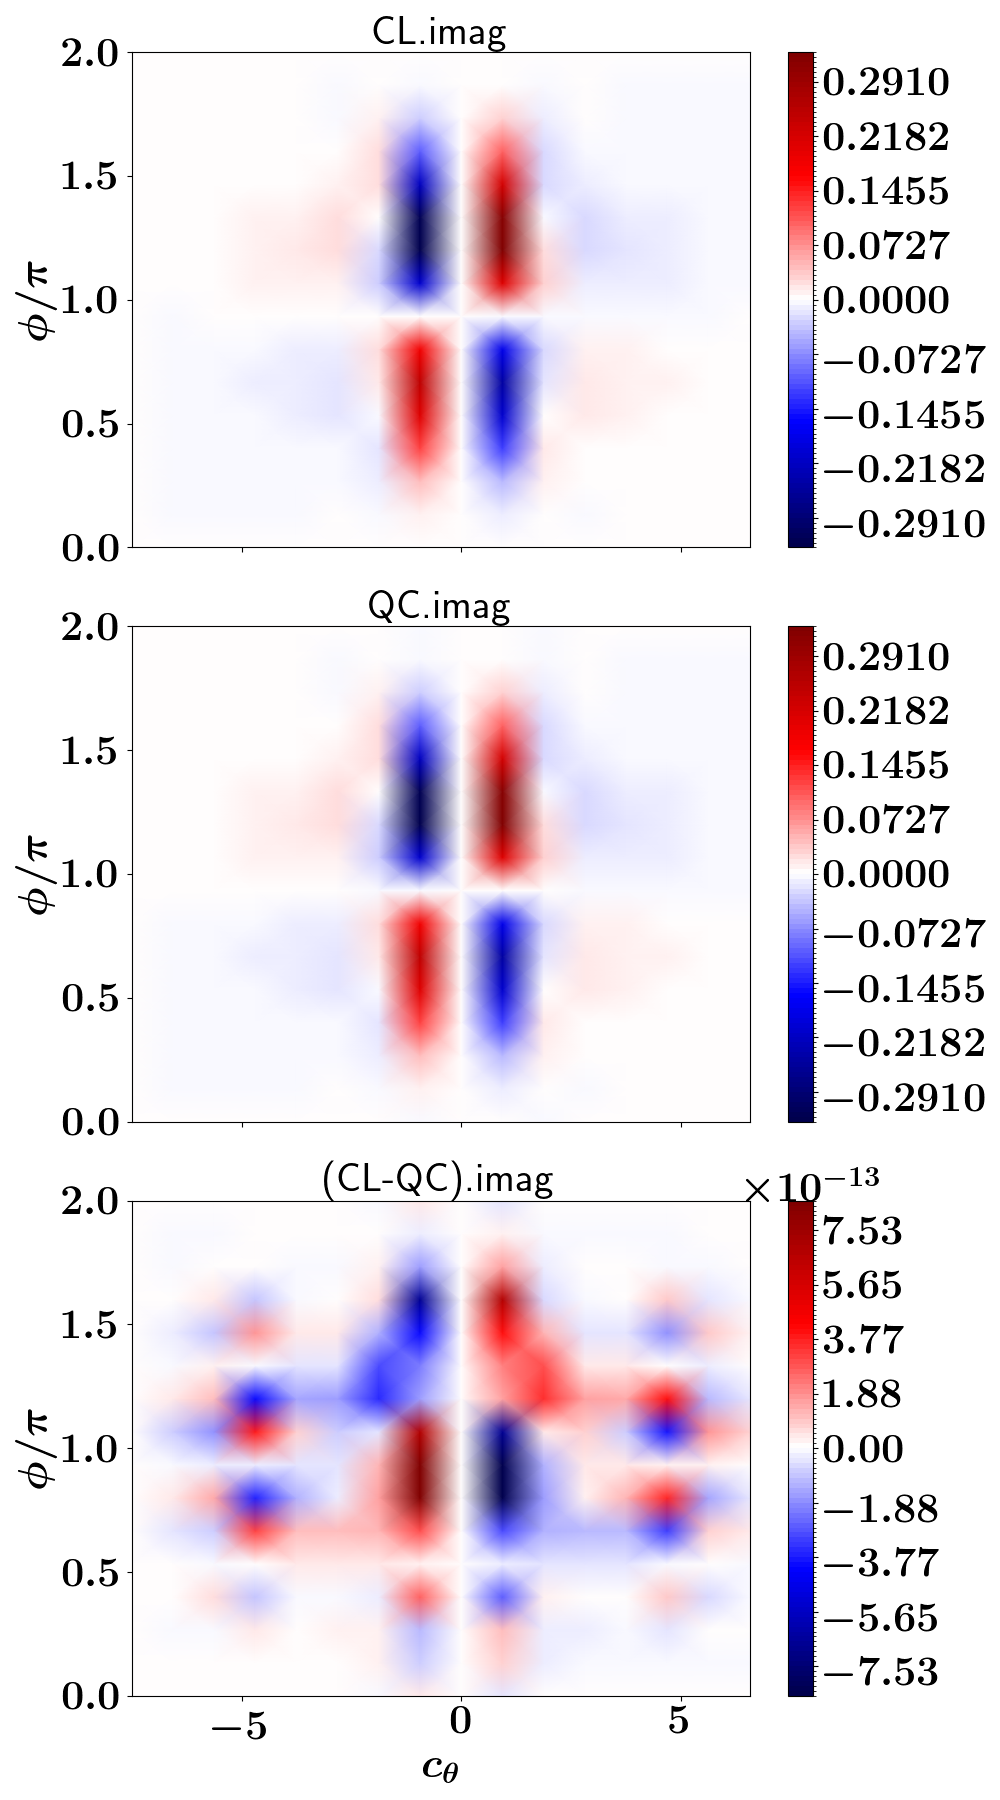

In [ ]:
# ------------------------------------------------------------
# --- Test: initialization ---
# ------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_qucf_init_FOURIER(path_qucf, file_qucf, flag_fourier_theta):
    def rearrange_fourier_elements(fft_2d_init):
        fft_signal = np.zeros((Nx, Nx), dtype=complex)
        fft_signal = np.fft.fftshift(fft_2d_init, axes=id_axis)

        max_ampl = np.max(np.abs(fft_signal))
        fft_signal /= max_ampl
        return fft_signal
    # ---------------------------------------------------------
    id_axis = 1 - int(flag_fourier_theta)

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf
    om.pname_ = file_qucf
    om.open()

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- Fourier grid ---
    coef_ff = 2.*np.pi
    dx = np.diff(x)[0]
    dk = coef_ff / (dx*Nx)
    k_array_pos = np.linspace(              0, coef_ff/(2*dx) - dk, Nx//2) 
    k_array_neg = np.linspace(-coef_ff/(2*dx),                 -dk, Nx//2)
    k_array = np.concatenate((k_array_neg, k_array_pos))

    # -------------------------------------
    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")

    # Fourier spectrum is properly arranged by the extra X gate after quantum Fourier
    f_qucf_2D = rearrange_into_2d(f_qucf, Nx)
    max_ampl = np.max(np.abs(f_qucf_2D))
    fft_qucf = f_qucf_2D / max_ampl

    # -------------------------------------
    # --- classical Fourier ---
    f_cl = f_init_2d_(x, Nx) 
    fft_cl = np.fft.fft(f_cl, axis=id_axis)
    fft_cl = rearrange_fourier_elements(fft_cl)

    # -------------------------------------
    # --- Errors ---
    # QuCF returns complex-conjugate of the classical signal
    err_abs_2D = fft_cl - fft_qucf
    print("max-abs-err: {:0.3e}".format(  np.max(np.abs(err_abs_2D))  ))

    diff_abs_2D = np.abs(fft_cl) - np.abs(fft_qucf)
    print("max-diff-abs-err: {:0.3e}".format(  np.max(np.abs(diff_abs_2D))  ))

    # -------------------------------------
    # --- Plotting ---    
    if flag_fourier_theta:
        X, Y = np.meshgrid(k_array, x/np.pi)
        label_x, label_y = '$c_{\\theta}$', "$\phi/\pi$"
    else:
        X, Y = np.meshgrid(x/np.pi, k_array)
        label_x, label_y = '$\\theta/\pi$', "$c_{\phi}$"

    fig1, axs = plt.subplots(3, 1, figsize=(10,18))
    plot_2D_subplot(axs[0], fig1, X, Y, np.abs(fft_cl.transpose()),     "abs(CL)",    label_x = "", label_y = label_y, flag_x = False)
    plot_2D_subplot(axs[1], fig1, X, Y, np.abs(fft_qucf.transpose()),   "abs(QC)",    label_x = "", label_y = label_y, flag_x = False)
    plot_2D_subplot(axs[2], fig1, X, Y, diff_abs_2D.transpose(), "abs(CL) - abs(QC)", label_x = label_x, label_y = label_y)

    fig1, axs = plt.subplots(3, 1, figsize=(10,18))
    plot_2D_subplot(axs[0], fig1, X, Y, fft_cl.imag.transpose(),     "CL.imag",      label_x = "", label_y = label_y, flag_x = False)
    plot_2D_subplot(axs[1], fig1, X, Y, fft_qucf.imag.transpose(),   "QC.imag",      label_x = "", label_y = label_y, flag_x = False)
    plot_2D_subplot(axs[2], fig1, X, Y, err_abs_2D.imag.transpose(), "(CL-QC).imag", label_x = label_x, label_y = label_y)

    plt.tight_layout()
    return
# -------------------------------------------------------------
plot_qucf_init_FOURIER(path_qucf_, file_qucf_, flag_fourier_theta = True)